# 03 - EDA đặc điểm dữ liệu

Notebook này dùng để mô tả **đặc điểm của dữ liệu sau làm sạch**, không đi sâu vào phân tích insight kinh doanh.

Trọng tâm gồm: quy mô dữ liệu, phạm vi thời gian, kiểu dữ liệu, missing value, duplicate, phân bố biến số, đặc điểm biến phân loại và độ phủ thời gian.

In [1]:
# Thiết lập môi trường chạy notebook
import site
import sys
from pathlib import Path

USER_SITE = site.getusersitepackages()
if Path(USER_SITE).exists() and USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

## 1. Đọc dữ liệu đầu vào

Đọc bảng `sales_final.csv` trong `data/clean`. Đây là dữ liệu đã được làm sạch và hợp nhất, dùng làm nền cho EDA mô tả, data mart, mô hình dự báo và Tableau.

In [2]:
DATA_PATH = PROJECT_DIR / 'data' / 'clean' / 'sales_final.csv'
QUALITY_PATH = PROJECT_DIR / 'data' / 'clean' / 'data_quality_overview.csv'

sales = pd.read_csv(DATA_PATH, parse_dates=['Ngày chứng từ'], low_memory=False)
quality = pd.read_csv(QUALITY_PATH) if QUALITY_PATH.exists() else pd.DataFrame()

print('Đường dẫn dữ liệu:', DATA_PATH)
print('Kích thước sales_final:', sales.shape)
display(sales.head())
if not quality.empty:
    display(quality)

Đường dẫn dữ liệu: c:\Dự án\DuAnTotNghiep\data\clean\sales_final.csv
Kích thước sales_final: (55054, 38)


,Ngày chứng từ,Năm,Tháng,Quý,Năm-Tháng,Số chứng từ,ĐVT,Số lượng,Khối lượng KG,Đơn giá,Doanh số,Chiết khấu,Doanh thu thuần,Số lượng trả lại,Giá trị trả lại,Giá vốn đơn vị,Tổng giá vốn,Lợi nhuận,Lợi nhuận tính lại,Mã khách hàng,Tên khách hàng,Nhóm khách hàng,Mã sản phẩm,Tên sản phẩm,Nhóm sản phẩm,Loại sản phẩm,Kênh,Chi nhánh,Vùng doanh thu,Trả hàng,Giai đoạn,Nguồn dữ liệu,Có dữ liệu giá vốn,Cờ duplicate,Biên lợi nhuận,Tỷ lệ chiết khấu,Tỷ lệ hoàn trả,Giá trị TB/dòng
0,2023-01-01,2023,1,1,2023-01,202300000277,Túi,1.00,0.20,"127,000.00","127,000.00",0.00,"127,000.00",0.00,0.00,"57,715.00","57,715.00","69,285.00","69,285.00",O_CUS_0008,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0002,Không có dữ liệu,Hòa tan,Không có dữ liệu,Online,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,False,0.55,0.00,0.00,"127,000.00"
1,2023-01-01,2023,1,1,2023-01,202300000393,KG,14.50,14.50,"181,000.00","2,624,500.00",0.00,"2,624,500.00",0.00,0.00,"144,510.76","2,095,406.00","529,094.00","529,094.00",O_CUS_0095,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0009,Không có dữ liệu,Rang xay,Không có dữ liệu,Khác,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,False,0.20,0.00,0.00,"2,624,500.00"
2,2023-01-01,2023,1,1,2023-01,202300000843,Hộp,3.00,0.90,"59,500.00","178,500.00",0.00,"178,500.00",0.00,0.00,"32,565.00","97,695.00","80,805.00","80,805.00",O_CUS_0006,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0006,Không có dữ liệu,Hòa tan,Không có dữ liệu,Online,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,False,0.45,0.00,0.00,"178,500.00"
3,2023-01-01,2023,1,1,2023-01,202300002038,Hộp,6.00,1.08,"47,600.00","285,600.00","13,335.00","272,265.00",0.00,0.00,"22,146.50","132,879.00","139,386.00","139,386.00",O_CUS_0006,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0025,Không có dữ liệu,Hòa tan,Không có dữ liệu,Online,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,False,0.51,0.05,0.00,"272,265.00"
4,2023-01-01,2023,1,1,2023-01,202300004095,Túi,8.00,12.80,"251,000.00","2,008,000.00",0.00,"2,008,000.00",0.00,0.00,"113,074.62","904,597.00","1,103,403.00","1,103,403.00",O_CUS_0149,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0001,Không có dữ liệu,Hòa tan,Không có dữ liệu,Khác,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,False,0.55,0.00,0.00,"2,008,000.00"


,Bảng,Số dòng,Số cột,Số ô null,Số dòng duplicate toàn dòng
0,raw_sales_2023_2025,34207,19,0,29
1,raw_sales_2026,20843,22,39469,14
2,raw_cost_2026,242,6,0,0
3,sales_2023_2025_clean,34207,29,68414,29
4,sales_2026_clean,20843,39,0,14
5,cost_2026_clean,242,6,0,0
6,sales_final,55050,38,5897,43


## 2. Tổng quan quy mô và phạm vi dữ liệu

Phần này mô tả số dòng, số cột, phạm vi ngày, số tháng, số chứng từ, số khách hàng và số sản phẩm trong dữ liệu.

,Chỉ tiêu,Giá trị
0,Số dòng,55054
1,Số cột,38
2,Ngày nhỏ nhất,2023-01-01 00:00:00
3,Ngày lớn nhất,2026-05-29 00:00:00
4,Số năm,4
5,Số tháng duy nhất,41
6,Số chứng từ duy nhất,35315
7,Số khách hàng duy nhất,380
8,Số sản phẩm duy nhất,337


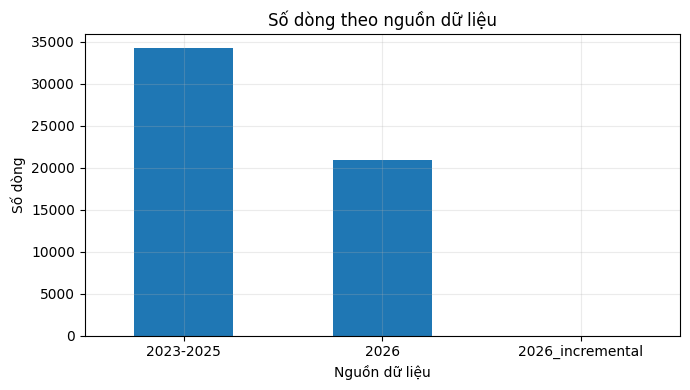

In [3]:
overview = pd.DataFrame({
    'Chỉ tiêu': [
        'Số dòng', 'Số cột', 'Ngày nhỏ nhất', 'Ngày lớn nhất', 'Số năm',
        'Số tháng duy nhất', 'Số chứng từ duy nhất', 'Số khách hàng duy nhất', 'Số sản phẩm duy nhất'
    ],
    'Giá trị': [
        len(sales), sales.shape[1], sales['Ngày chứng từ'].min(), sales['Ngày chứng từ'].max(),
        sales['Năm'].nunique(dropna=False), sales['Năm-Tháng'].nunique(dropna=False),
        sales['Số chứng từ'].nunique(dropna=False), sales['Mã khách hàng'].nunique(dropna=False),
        sales['Mã sản phẩm'].nunique(dropna=False)
    ]
})
display(overview)

fig, ax = plt.subplots(figsize=(7, 4))
sales['Nguồn dữ liệu'].value_counts(dropna=False).plot(kind='bar', ax=ax)
ax.set_title('Số dòng theo nguồn dữ liệu')
ax.set_xlabel('Nguồn dữ liệu')
ax.set_ylabel('Số dòng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Nhóm cột và kiểu dữ liệu

Phân loại các cột theo nhóm thời gian, định danh, phân loại/text, số liệu và cờ logic để hiểu cấu trúc dữ liệu trước khi phân tích.

,Nhóm cột,Số cột,Danh sách cột
0,Thời gian,5,"[Ngày chứng từ, Năm, Tháng, Quý, Năm-Tháng]"
1,Định danh,3,"[Số chứng từ, Mã khách hàng, Mã sản phẩm]"
2,Phân loại/Text,12,"[ĐVT, Tên khách hàng, Nhóm khách hàng, Tên sản..."
3,Số liệu,16,"[Số lượng, Khối lượng KG, Đơn giá, Doanh số, C..."
4,Cờ logic,2,"[Có dữ liệu giá vốn, Cờ duplicate]"


,Kiểu dữ liệu,Số cột
0,str,16
1,float64,16
2,int64,3
3,bool,2
4,datetime64[us],1


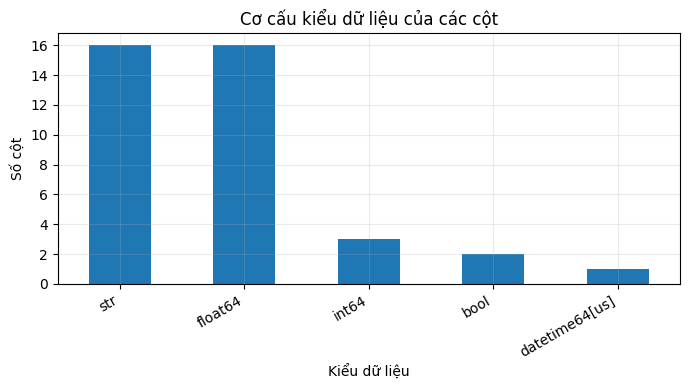

In [4]:
date_cols = ['Ngày chứng từ', 'Năm', 'Tháng', 'Quý', 'Năm-Tháng']
id_cols = ['Số chứng từ', 'Mã khách hàng', 'Mã sản phẩm']
text_cols = ['ĐVT', 'Tên khách hàng', 'Nhóm khách hàng', 'Tên sản phẩm', 'Nhóm sản phẩm', 'Loại sản phẩm', 'Kênh', 'Chi nhánh', 'Vùng doanh thu', 'Trả hàng', 'Giai đoạn', 'Nguồn dữ liệu']
num_cols = ['Số lượng', 'Khối lượng KG', 'Đơn giá', 'Doanh số', 'Chiết khấu', 'Doanh thu thuần', 'Số lượng trả lại', 'Giá trị trả lại', 'Giá vốn đơn vị', 'Tổng giá vốn', 'Lợi nhuận', 'Lợi nhuận tính lại', 'Biên lợi nhuận', 'Tỷ lệ chiết khấu', 'Tỷ lệ hoàn trả', 'Giá trị TB/dòng']
flag_cols = ['Có dữ liệu giá vốn', 'Cờ duplicate']

column_groups = pd.DataFrame({
    'Nhóm cột': ['Thời gian', 'Định danh', 'Phân loại/Text', 'Số liệu', 'Cờ logic'],
    'Số cột': [len(date_cols), len(id_cols), len(text_cols), len(num_cols), len(flag_cols)],
    'Danh sách cột': [date_cols, id_cols, text_cols, num_cols, flag_cols]
})
display(column_groups)

dtype_summary = sales.dtypes.astype(str).value_counts().rename_axis('Kiểu dữ liệu').reset_index(name='Số cột')
display(dtype_summary)

fig, ax = plt.subplots(figsize=(7, 4))
dtype_summary.plot(kind='bar', x='Kiểu dữ liệu', y='Số cột', legend=False, ax=ax)
ax.set_title('Cơ cấu kiểu dữ liệu của các cột')
ax.set_xlabel('Kiểu dữ liệu')
ax.set_ylabel('Số cột')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Missing value

Mô tả mức độ thiếu dữ liệu theo từng cột và theo nguồn dữ liệu. Phần này chỉ mô tả đặc điểm dữ liệu, chưa đánh giá insight kinh doanh.

,Cột,Số null,Tỷ lệ null
34,Biên lợi nhuận,1979,0.04
35,Tỷ lệ chiết khấu,1962,0.04
36,Tỷ lệ hoàn trả,1962,0.04
2,Tháng,0,0.00
0,Ngày chứng từ,0,0.00


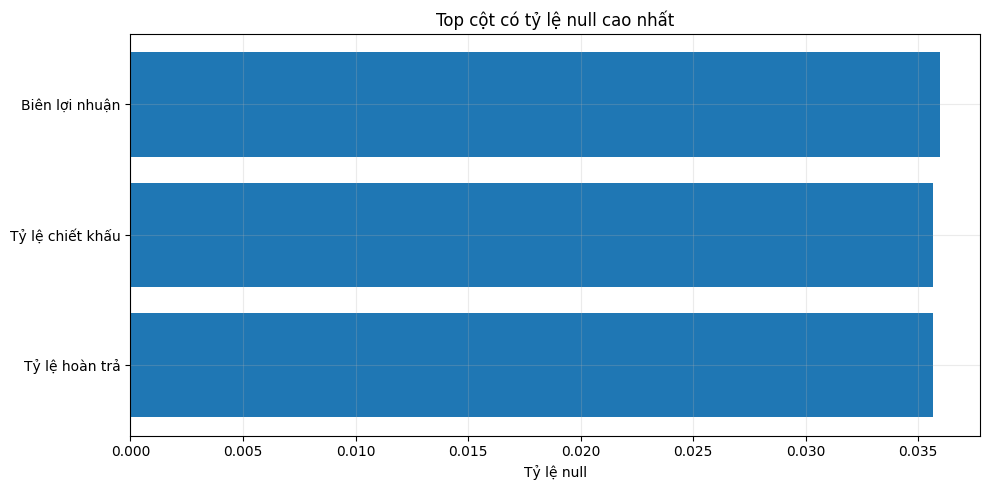

Nguồn dữ liệu,2023-2025,2026,2026_incremental
Biên lợi nhuận,0.04,0.03,0.50
Tỷ lệ chiết khấu,0.04,0.03,0.50
Tỷ lệ hoàn trả,0.04,0.03,0.50


In [5]:
missing = pd.DataFrame({
    'Cột': sales.columns,
    'Số null': sales.isna().sum().values,
    'Tỷ lệ null': sales.isna().mean().values,
}).sort_values('Số null', ascending=False)
display(missing.head())

missing_top = missing[missing['Số null'] > 0].head(20)
if len(missing_top) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(missing_top['Cột'], missing_top['Tỷ lệ null'])
    ax.set_title('Top cột có tỷ lệ null cao nhất')
    ax.set_xlabel('Tỷ lệ null')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Không có cột nào còn null.')

missing_by_source = sales.groupby('Nguồn dữ liệu', dropna=False).apply(lambda df: df.isna().mean()).T
missing_by_source = missing_by_source.loc[missing_by_source.max(axis=1) > 0]
display(missing_by_source.head())


## 5. Duplicate

Mô tả duplicate toàn dòng và cờ duplicate. Với dữ liệu hóa đơn, duplicate được hiển thị để giải thích chất lượng dữ liệu, không tự động xóa nếu chưa có căn cứ nghiệp vụ.

,Chỉ tiêu,Giá trị
0,Số dòng duplicate toàn bộ,3.00
1,Tỷ lệ duplicate toàn bộ,0.00
2,Số dòng có Cờ duplicate = True,43.00
3,Tỷ lệ Cờ duplicate = True,0.00


,Nguồn dữ liệu,Số dòng có cờ duplicate,Tỷ lệ,Số dòng
0,2023-2025,29,0.00,34207
1,2026,14,0.00,20843
2,2026_incremental,0,0.00,4


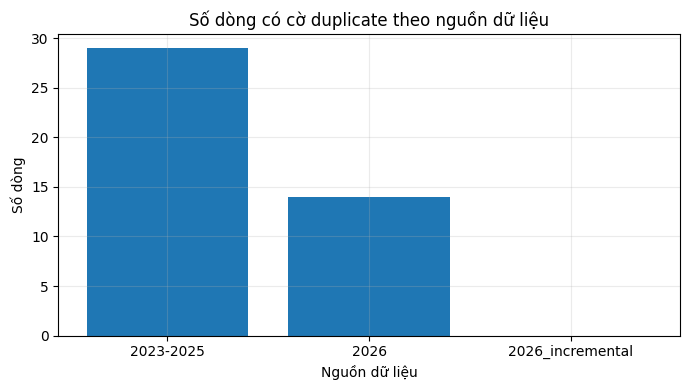

,Ngày chứng từ,Năm,Tháng,Quý,Năm-Tháng,Số chứng từ,ĐVT,Số lượng,Khối lượng KG,Đơn giá,Doanh số,Chiết khấu,Doanh thu thuần,Số lượng trả lại,Giá trị trả lại,Giá vốn đơn vị,Tổng giá vốn,Lợi nhuận,Lợi nhuận tính lại,Mã khách hàng,Tên khách hàng,Nhóm khách hàng,Mã sản phẩm,Tên sản phẩm,Nhóm sản phẩm,Loại sản phẩm,Kênh,Chi nhánh,Vùng doanh thu,Trả hàng,Giai đoạn,Nguồn dữ liệu,Có dữ liệu giá vốn,Cờ duplicate,Biên lợi nhuận,Tỷ lệ chiết khấu,Tỷ lệ hoàn trả,Giá trị TB/dòng
21387,2025-01-11,2025,1,1,2025-01,GL250111.009,Hộp,1.00,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,O_CUS_0062,Không có dữ liệu,Nhóm khách hàng nước ngoài,O_PRO_0045,Không có dữ liệu,Hòa tan,Không có dữ liệu,Xuất khẩu,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,True,NaN,NaN,NaN,0.00
23946,2025-03-31,2025,3,1,2025-03,GL250331.001,Gói,4.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,O_CUS_0019,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0051,Không có dữ liệu,Hòa tan,Không có dữ liệu,Khác,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,True,NaN,NaN,NaN,0.00
24258,2025-04-10,2025,4,2,2025-04,GL250410.011,KG,0.50,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,O_CUS_0019,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0028,Không có dữ liệu,Rang xay,Không có dữ liệu,Khác,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,True,NaN,NaN,NaN,0.00
24552,2025-04-22,2025,4,2,2025-04,GL250422.002,KG,0.50,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,O_CUS_0019,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0011,Không có dữ liệu,Rang xay,Không có dữ liệu,Khác,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,True,NaN,NaN,NaN,0.00
25431,2025-05-21,2025,5,2,2025-05,GL250521.027,KG,0.50,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,O_CUS_0019,Không có dữ liệu,Nhóm khách hàng nội địa,O_PRO_0011,Không có dữ liệu,Rang xay,Không có dữ liệu,Khác,Không áp dụng,Không áp dụng,Không,Trước tái cấu trúc,2023-2025,False,True,NaN,NaN,NaN,0.00


In [6]:
duplicate_summary = pd.DataFrame({
    'Chỉ tiêu': ['Số dòng duplicate toàn bộ', 'Tỷ lệ duplicate toàn bộ', 'Số dòng có Cờ duplicate = True', 'Tỷ lệ Cờ duplicate = True'],
    'Giá trị': [
        int(sales.duplicated().sum()),
        sales.duplicated().mean(),
        int(sales['Cờ duplicate'].astype(str).str.lower().eq('true').sum()) if 'Cờ duplicate' in sales.columns else np.nan,
        sales['Cờ duplicate'].astype(str).str.lower().eq('true').mean() if 'Cờ duplicate' in sales.columns else np.nan,
    ]
})
display(duplicate_summary)

if 'Cờ duplicate' in sales.columns:
    dup_by_source = sales.assign(Cờ_duplicate_bool=sales['Cờ duplicate'].astype(str).str.lower().eq('true')).groupby('Nguồn dữ liệu', dropna=False)['Cờ_duplicate_bool'].agg(['sum', 'mean', 'count']).reset_index()
    dup_by_source.columns = ['Nguồn dữ liệu', 'Số dòng có cờ duplicate', 'Tỷ lệ', 'Số dòng']
    display(dup_by_source)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(dup_by_source['Nguồn dữ liệu'], dup_by_source['Số dòng có cờ duplicate'])
    ax.set_title('Số dòng có cờ duplicate theo nguồn dữ liệu')
    ax.set_xlabel('Nguồn dữ liệu')
    ax.set_ylabel('Số dòng')
    plt.tight_layout()
    plt.show()

    display(sales[sales['Cờ duplicate'].astype(str).str.lower().eq('true')].head())


## 6. Đặc điểm các biến số

Mô tả phân bố, trung vị, độ lệch, giá trị nhỏ nhất/lớn nhất và tỷ lệ xuất hiện giá trị 0 hoặc âm ở các biến số.

,count,mean,std,min,25%,50%,75%,max,Số null,Số giá trị 0,Số giá trị âm
Số lượng,"55,054.00",77.99,"3,808.51","-20,000.00",1.00,2.00,7.50,"525,000.00",0,230,865
Khối lượng KG,"55,054.00",17.74,334.63,-288.00,0.11,0.80,4.50,"23,400.00",0,11544,856
Đơn giá,"55,054.00","152,590.99","1,061,276.82","-37,667.00","42,000.00","130,000.00","187,000.00","246,751,999.76",0,1742,1
Doanh số,"55,054.00","2,529,995.79","56,354,715.92","-6,000,000,000.00","52,000.00","219,722.22","1,053,000.00","6,000,000,000.00",0,1962,852
Chiết khấu,"55,054.00","5,396.89","59,626.74",0.00,0.00,0.00,0.00,"4,166,667.00",0,50658,0
Doanh thu thuần,"55,054.00","2,525,658.81","52,901,785.15","-6,000,000,000.00","52,000.00","231,481.48","1,069,200.00","6,000,000,000.00",0,1979,858
Số lượng trả lại,"55,054.00",0.01,0.64,0.00,0.00,0.00,0.00,96.00,0,54956,0
Giá trị trả lại,"55,054.00","1,229.10","57,408.81",0.00,0.00,0.00,0.00,"7,333,333.00",0,54957,0
Giá vốn đơn vị,"55,054.00","105,547.05","123,851.35","-199,996.00","19,487.00","66,147.00","143,191.00","2,025,502.66",0,1450,4
Tổng giá vốn,"55,054.00","1,887,583.39","34,053,419.74","-2,489,400,000.00","24,475.00","133,171.50","667,882.25","2,489,400,000.00",0,1680,856


,Cột,Tỷ lệ bằng 0,Tỷ lệ âm
0,Số lượng,0.00,0.02
1,Khối lượng KG,0.21,0.02
2,Đơn giá,0.03,0.00
3,Doanh số,0.04,0.02
4,Chiết khấu,0.92,0.00
5,Doanh thu thuần,0.04,0.02
6,Số lượng trả lại,1.00,0.00
7,Giá trị trả lại,1.00,0.00
8,Giá vốn đơn vị,0.03,0.00
9,Tổng giá vốn,0.03,0.02


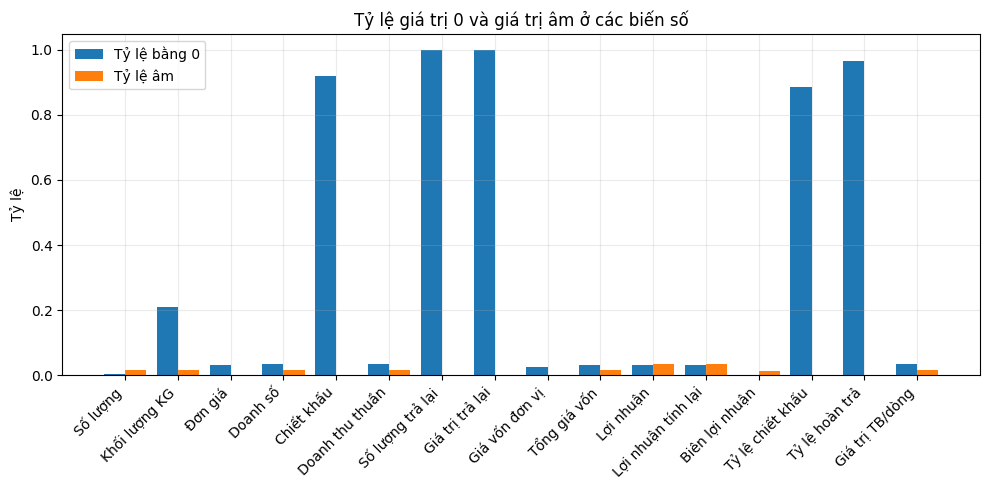

In [7]:
num_existing = [col for col in num_cols if col in sales.columns]
for col in num_existing:
    sales[col] = pd.to_numeric(sales[col], errors='coerce')

numeric_profile = sales[num_existing].describe(percentiles=[0.25, 0.5, 0.75]).T
numeric_profile['Số null'] = sales[num_existing].isna().sum()
numeric_profile['Số giá trị 0'] = (sales[num_existing] == 0).sum()
numeric_profile['Số giá trị âm'] = (sales[num_existing] < 0).sum()
display(numeric_profile)

zero_negative = pd.DataFrame({
    'Cột': num_existing,
    'Tỷ lệ bằng 0': [(sales[col] == 0).mean() for col in num_existing],
    'Tỷ lệ âm': [(sales[col] < 0).mean() for col in num_existing],
})
display(zero_negative)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(zero_negative))
ax.bar(x - 0.2, zero_negative['Tỷ lệ bằng 0'], width=0.4, label='Tỷ lệ bằng 0')
ax.bar(x + 0.2, zero_negative['Tỷ lệ âm'], width=0.4, label='Tỷ lệ âm')
ax.set_title('Tỷ lệ giá trị 0 và giá trị âm ở các biến số')
ax.set_xticks(x)
ax.set_xticklabels(zero_negative['Cột'], rotation=45, ha='right')
ax.set_ylabel('Tỷ lệ')
ax.legend()
plt.tight_layout()
plt.show()


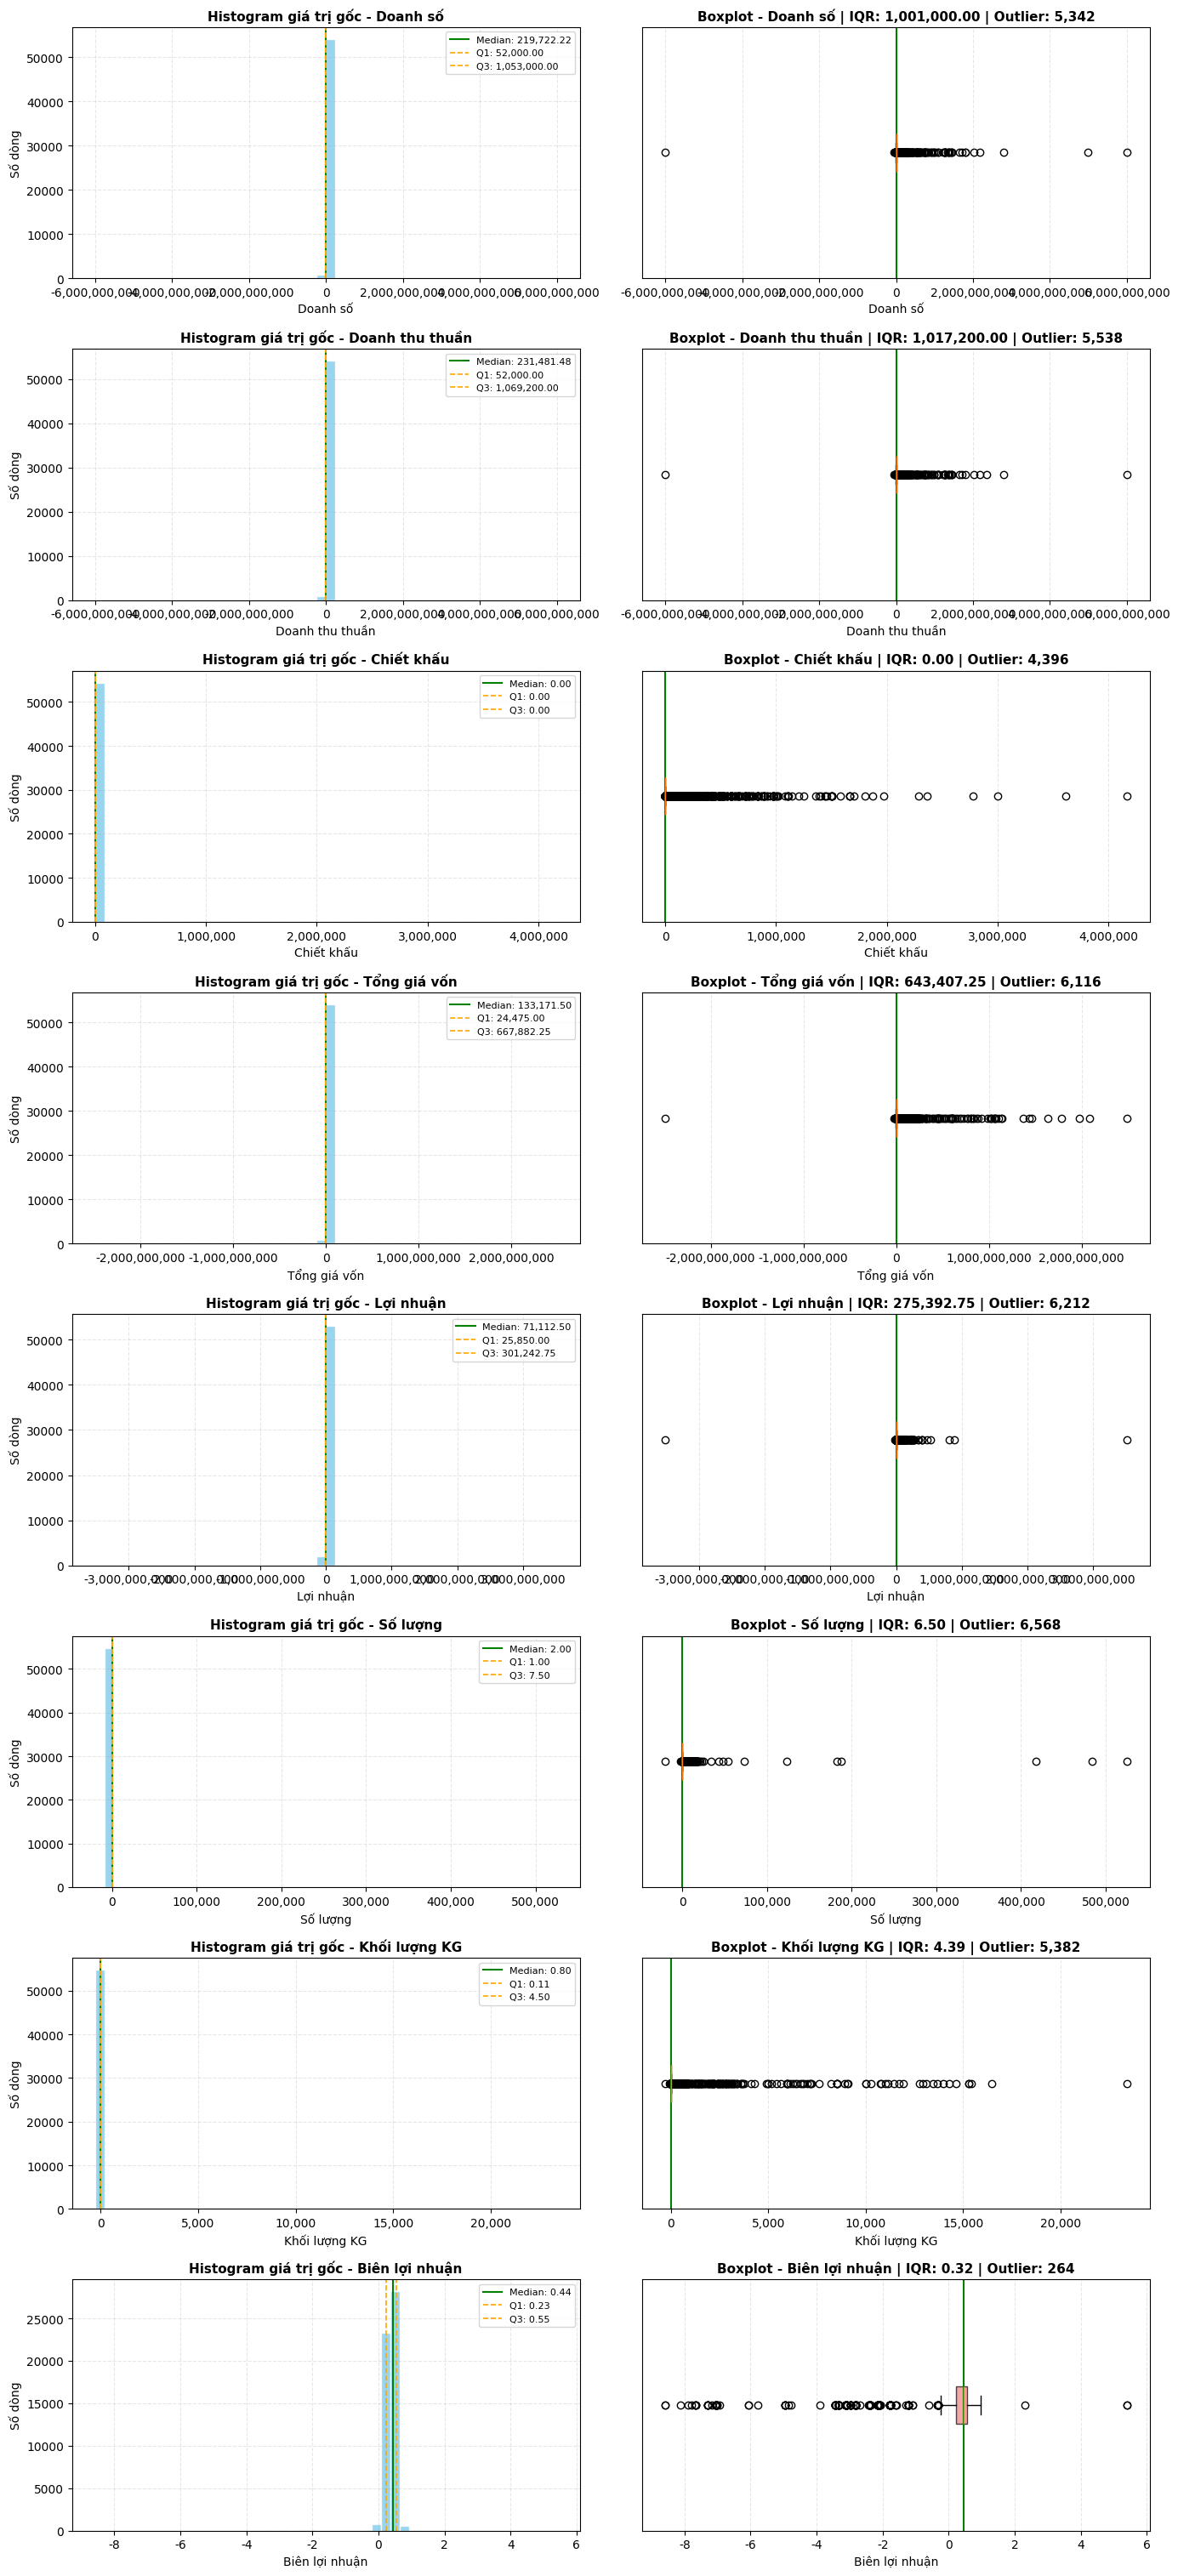

In [8]:
import matplotlib.ticker as ticker

# Histogram mô tả phân bố giá trị gốc; boxplot bên cạnh giúp nhìn median, IQR và outlier.
plot_numeric_cols = ['Doanh số', 'Doanh thu thuần', 'Chiết khấu', 'Tổng giá vốn', 'Lợi nhuận', 'Số lượng', 'Khối lượng KG', 'Biên lợi nhuận']
plot_numeric_cols = [col for col in plot_numeric_cols if col in sales.columns]

n_rows = len(plot_numeric_cols)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3.8 * n_rows))

for i, col in enumerate(plot_numeric_cols):
    values = pd.to_numeric(sales[col], errors='coerce').dropna()

    if values.empty:
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
        continue

    q1 = values.quantile(0.25)
    median = values.median()
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outlier_count = ((values < lower_fence) | (values > upper_fence)).sum()

    axes[i, 0].hist(values, bins=50, color='skyblue', edgecolor='white', alpha=0.85)
    axes[i, 0].axvline(median, color='green', linestyle='-', linewidth=1.5, label=f"Median: {median:,.2f}")
    axes[i, 0].axvline(q1, color='orange', linestyle='--', linewidth=1.2, label=f"Q1: {q1:,.2f}")
    axes[i, 0].axvline(q3, color='orange', linestyle='--', linewidth=1.2, label=f"Q3: {q3:,.2f}")
    axes[i, 0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
    axes[i, 0].set_title(f'Histogram giá trị gốc - {col}', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Số dòng')
    axes[i, 0].grid(True, linestyle='--', alpha=0.3)
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].boxplot(values, vert=False, showfliers=True, patch_artist=True, boxprops={'facecolor': 'lightcoral', 'alpha': 0.7})
    axes[i, 1].axvline(median, color='green', linestyle='-', linewidth=1.5)
    axes[i, 1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
    axes[i, 1].set_title(f'Boxplot - {col} | IQR: {iqr:,.2f} | Outlier: {outlier_count:,.0f}', fontsize=11, fontweight='bold')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_yticks([])
    axes[i, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Đặc điểm các biến phân loại

Xem số lượng giá trị khác nhau của từng cột phân loại và top giá trị xuất hiện nhiều nhất. Đây là cách kiểm tra dữ liệu text đã được chuẩn hóa ổn chưa.

,Cột,Số giá trị duy nhất,Tỷ lệ unique/dòng,Số null
12,Số chứng từ,35315,0.64,0
13,Mã khách hàng,380,0.01,0
14,Mã sản phẩm,337,0.01,0
3,Tên sản phẩm,243,0.00,0
1,Tên khách hàng,156,0.00,0
0,ĐVT,15,0.00,0
2,Nhóm khách hàng,12,0.00,0
5,Loại sản phẩm,12,0.00,0
8,Vùng doanh thu,9,0.00,0
6,Kênh,8,0.00,0


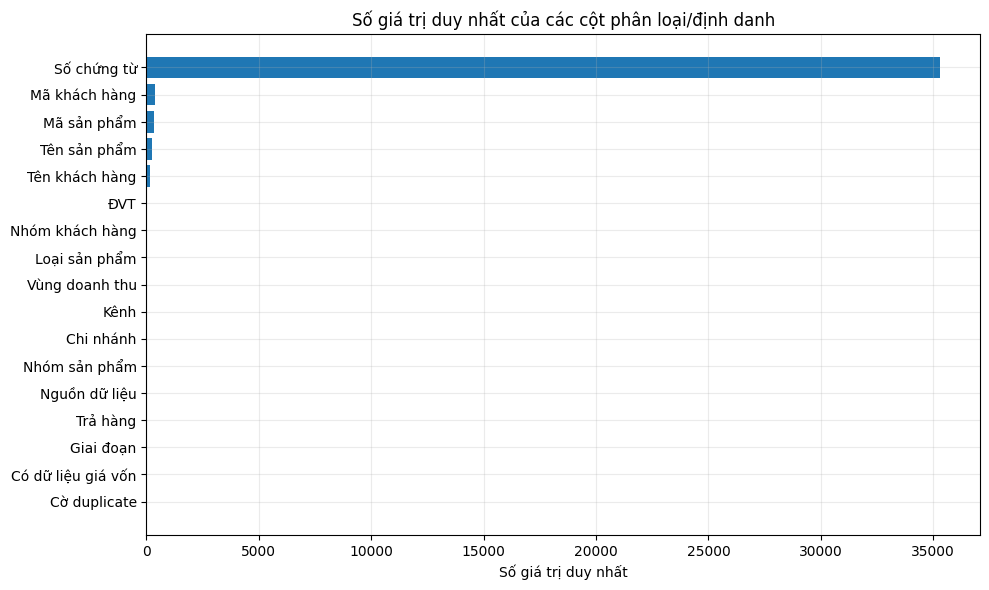

In [9]:
cat_existing = [col for col in text_cols + id_cols + flag_cols if col in sales.columns]
cat_profile = pd.DataFrame({
    'Cột': cat_existing,
    'Số giá trị duy nhất': [sales[col].nunique(dropna=False) for col in cat_existing],
    'Tỷ lệ unique/dòng': [sales[col].nunique(dropna=False) / len(sales) for col in cat_existing],
    'Số null': [sales[col].isna().sum() for col in cat_existing],
}).sort_values('Số giá trị duy nhất', ascending=False)
display(cat_profile)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_profile['Cột'], cat_profile['Số giá trị duy nhất'])
ax.set_title('Số giá trị duy nhất của các cột phân loại/định danh')
ax.set_xlabel('Số giá trị duy nhất')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,Nguồn dữ liệu,Số dòng
0,2023-2025,34207
1,2026,20843
2,2026_incremental,4


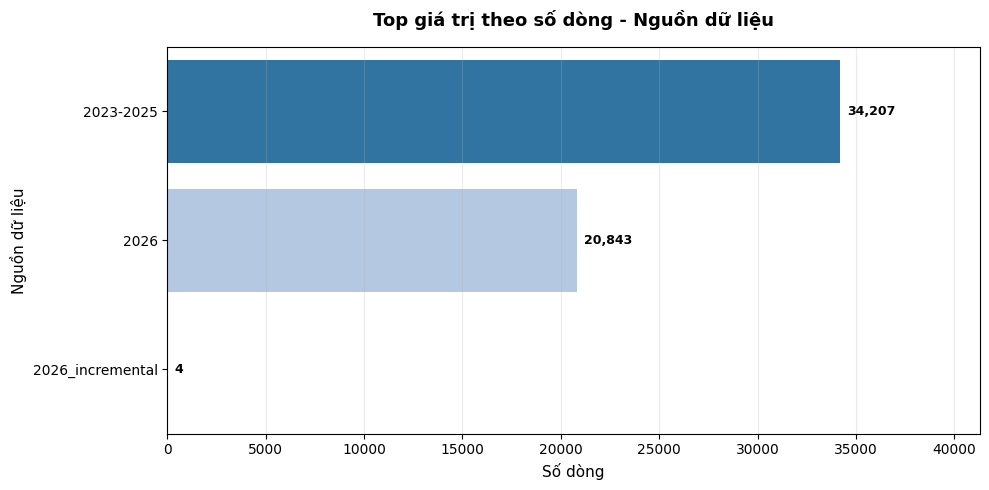

,Giai đoạn,Số dòng
0,Trước tái cấu trúc,34207
1,Sau tái cấu trúc,20847


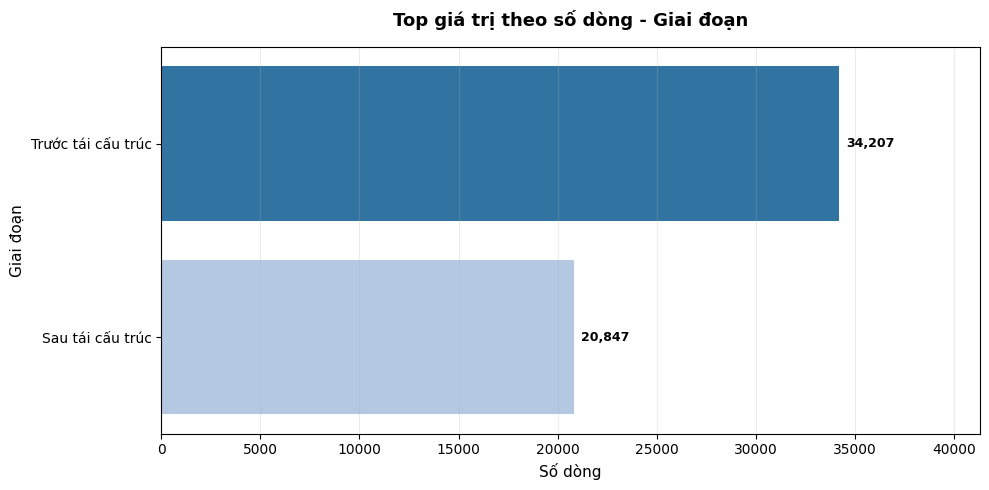

,Kênh,Số dòng
0,Quán nội bộ,19280
1,Online,19015
2,Khác,14049
3,GT,1345
4,HORECA,665
5,MT,378
6,Xuất khẩu,300
7,OEM,22


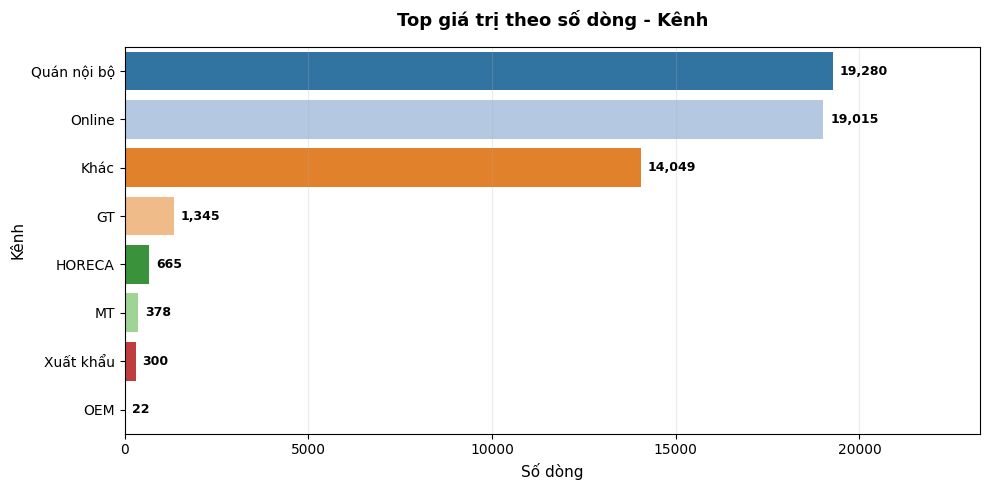

,Nhóm khách hàng,Số dòng
0,Nhóm khách hàng nội địa,33910
1,Internal,14692
2,Online,3962
3,F&B,818
4,Distributor,601
5,Corporate,305
6,Airport,224
7,Retail,220
8,Nhóm khách hàng nước ngoài,169
9,Nhóm khách hàng xuất khẩu,128


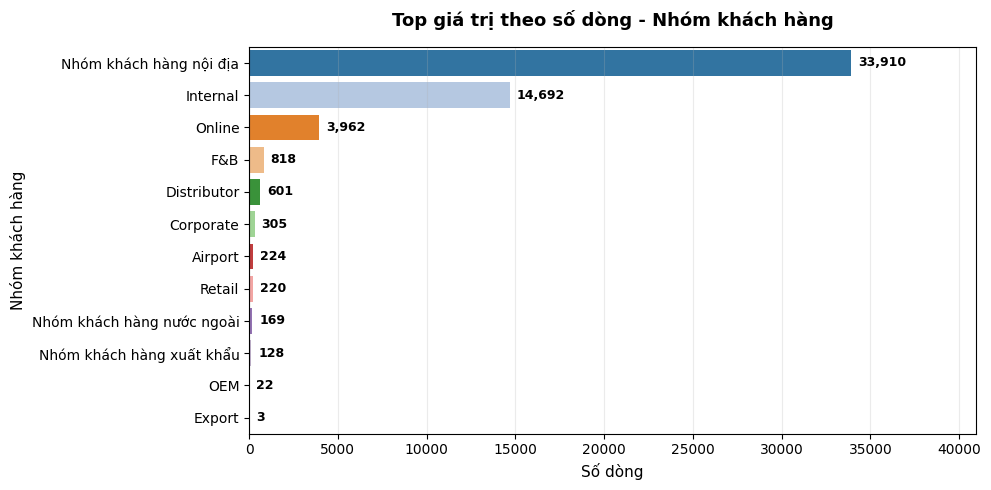

,Nhóm sản phẩm,Số dòng
0,Rang xay,24141
1,Hòa tan,19453
2,Đồ uống,11396
3,Khác,64


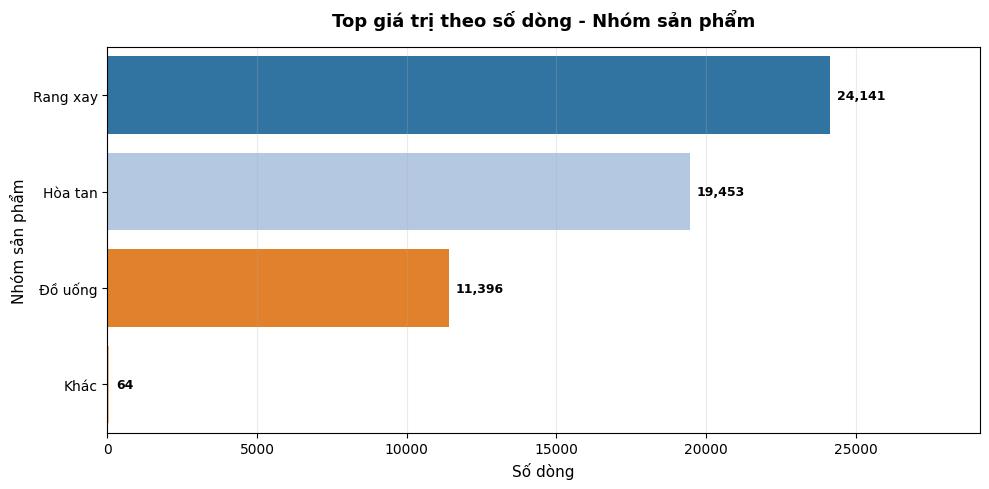

,Loại sản phẩm,Số dòng
0,Không có dữ liệu,34207
1,Thức uống cà phê,8374
2,Cà phê rang xay,4976
3,Cà phê hòa tan,4411
4,Nước ép,1021
5,Trà,862
6,Đá xay,448
7,Thức uống đóng chai,374
8,Chocolate,175
9,Sữa,107


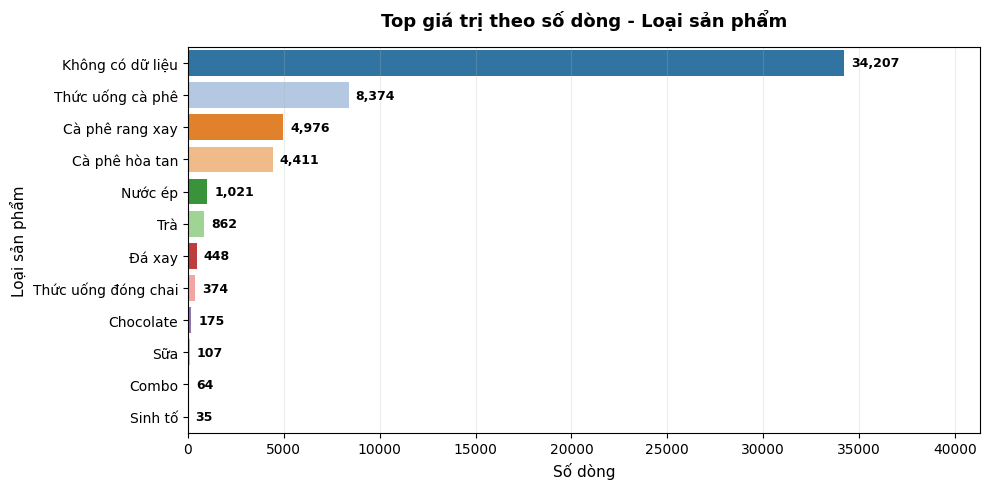

,ĐVT,Số dòng
0,KG,19830
1,Hộp,13264
2,Ly,10957
3,Túi,8350
4,Gói,1777
5,Lon,602
6,Chai,123
7,Thùng,52
8,Lần,36
9,Hộp nhỏ,20


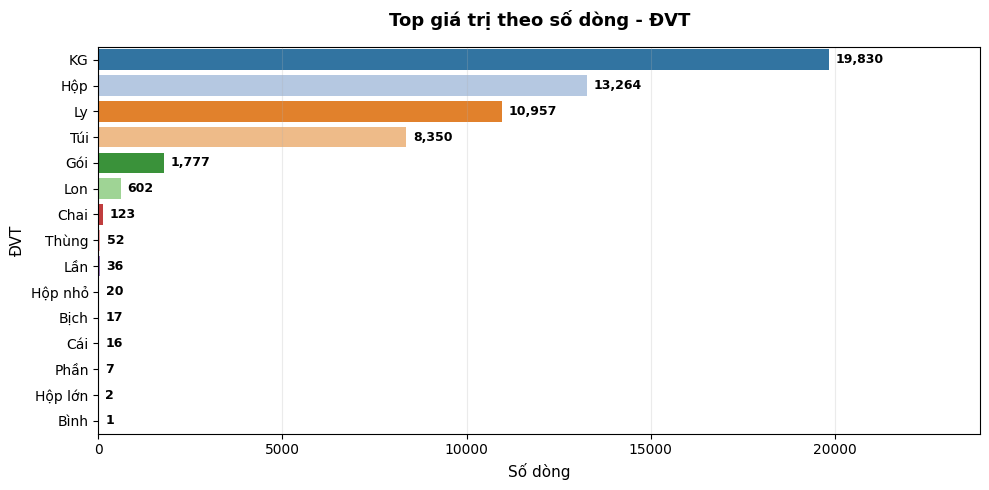

,Chi nhánh,Số dòng
0,Không áp dụng,34207
1,Công ty,6155
2,Quán Tây Nguyên 2,5797
3,Quán Tây Nguyên 1,4816
4,Quán HCM,4079


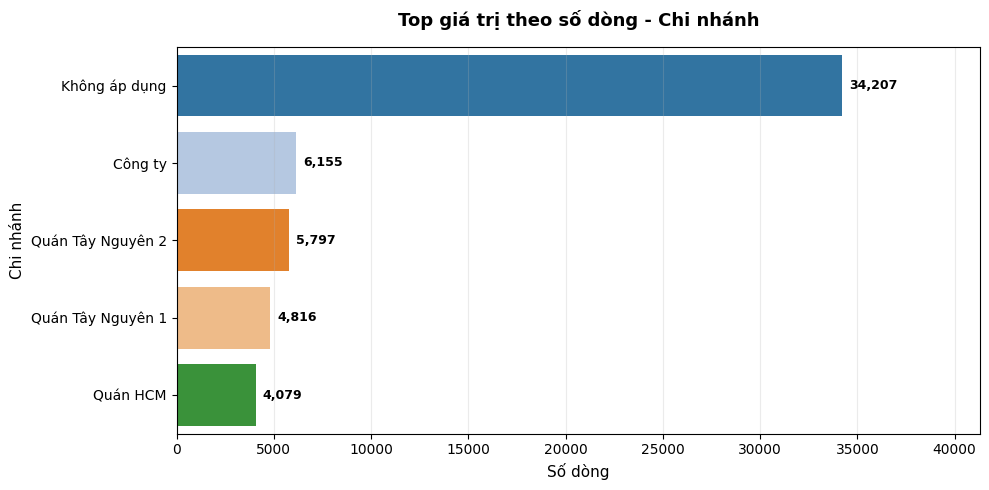

,Vùng doanh thu,Số dòng
0,Không áp dụng,34207
1,Miền Trung - Tây Nguyên,12000
2,Hồ Chí Minh,4647
3,Online,3957
4,Miền Bắc,122
5,Miền Tây,77
6,OEM,22
7,Miền Đông,20
8,Nước ngoài,2


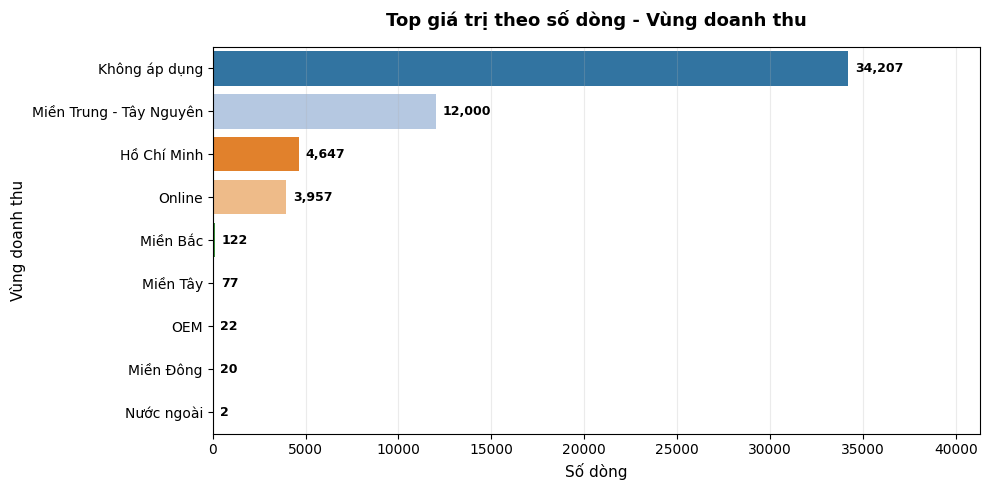

,Trả hàng,Số dòng
0,Không,54107
1,Có,947


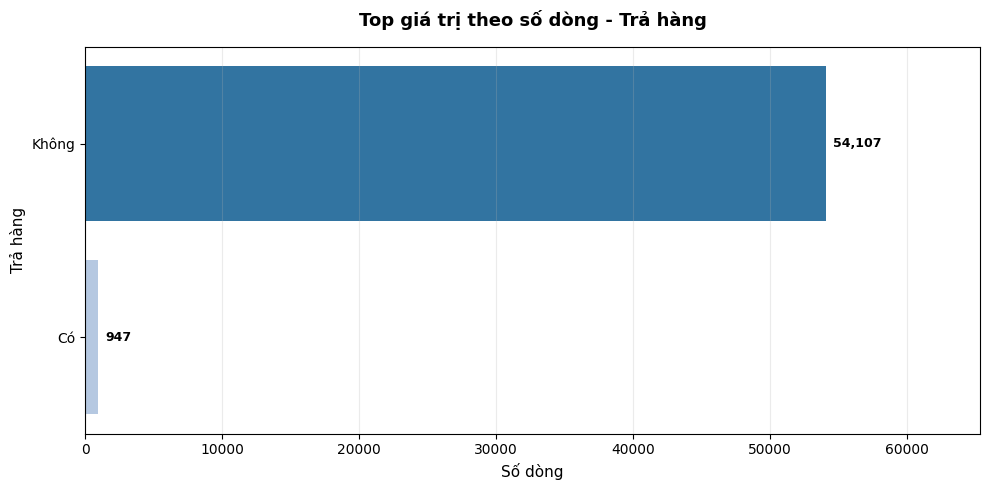

In [10]:
pd.options.display.float_format = '{:.6f}'.format
main_category_cols = ['Nguồn dữ liệu', 'Giai đoạn', 'Kênh', 'Nhóm khách hàng', 'Nhóm sản phẩm', 'Loại sản phẩm', 'ĐVT', 'Chi nhánh', 'Vùng doanh thu', 'Trả hàng']
main_category_cols = [col for col in main_category_cols if col in sales.columns]

for col in main_category_cols:
    vc = sales[col].value_counts(dropna=False).head(15).reset_index(name='Số dòng')
    vc[col] = vc[col].astype(str)
    display(vc)

    fig, ax = plt.subplots(figsize=(10, 5))
    vc_sorted = vc.sort_values('Số dòng', ascending=False)

    sns.barplot(
        data=vc_sorted,
        y=col,
        x='Số dòng',
        hue=col,
        ax=ax,
        palette='tab20',
        legend=False,
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize=9, fontweight='bold')

    ax.set_title(f'Top giá trị theo số dòng - {col}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Số dòng', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

    plt.tight_layout()
    plt.show()


## 8. Độ phủ thời gian

Mô tả số dòng theo tháng và năm để kiểm tra dữ liệu có đủ các tháng hay không. Đây là bước nền trước khi phân tích biến động và xây dựng mô hình dự báo.

,Năm,Tháng,Nguồn dữ liệu,Số dòng
0,2023,1,2023-2025,864
1,2023,2,2023-2025,682
2,2023,3,2023-2025,909
3,2023,4,2023-2025,708
4,2023,5,2023-2025,689


Năm,2023,2024,2025,2026
Tháng,,,,
1,864.000000,877.000000,1192.000000,4453.000000
2,682.000000,635.000000,827.000000,3524.000000
3,909.000000,880.000000,939.000000,4250.000000
4,708.000000,655.000000,855.000000,4256.000000
5,689.000000,778.000000,962.000000,4364.000000
6,782.000000,822.000000,987.000000,NaN
7,873.000000,839.000000,1063.000000,NaN
8,873.000000,917.000000,1075.000000,NaN
9,807.000000,827.000000,1186.000000,NaN


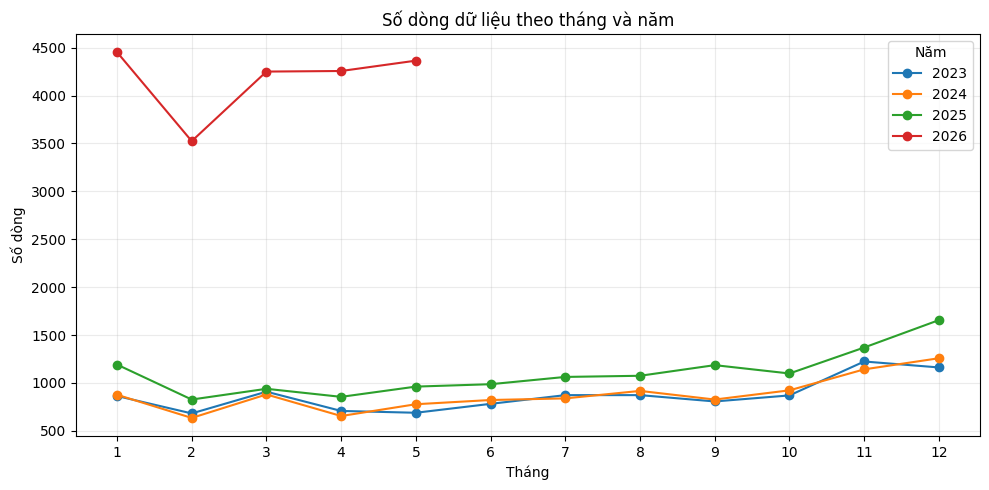

In [11]:
time_count = sales.groupby(['Năm', 'Tháng', 'Nguồn dữ liệu'], dropna=False).size().reset_index(name='Số dòng')
display(time_count.head())

monthly_count = sales.groupby(['Năm', 'Tháng'], dropna=False).size().reset_index(name='Số dòng')
pivot_count = monthly_count.pivot(index='Tháng', columns='Năm', values='Số dòng').sort_index()
display(pivot_count)

fig, ax = plt.subplots(figsize=(10, 5))
for year in sorted(sales['Năm'].dropna().unique()):
    sub = monthly_count[monthly_count['Năm'] == year].sort_values('Tháng')
    ax.plot(sub['Tháng'], sub['Số dòng'], marker='o', label=str(year))
ax.set_title('Số dòng dữ liệu theo tháng và năm')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số dòng')
ax.set_xticks(range(1, 13))
ax.legend(title='Năm')
plt.tight_layout()
plt.show()




## 9. Ma trận tương quan biến số

Ma trận tương quan chỉ dùng để mô tả quan hệ tuyến tính giữa các biến số, chưa đưa ra kết luận nguyên nhân hay hiệu quả kinh doanh.

,Số lượng,Khối lượng KG,Đơn giá,Doanh số,Chiết khấu,Doanh thu thuần,Giá trị trả lại,Tổng giá vốn,Lợi nhuận,Biên lợi nhuận,Tỷ lệ chiết khấu,Tỷ lệ hoàn trả
Số lượng,1.000000,0.263883,-0.002314,0.166420,-0.000865,0.167829,-0.000437,0.188287,0.107054,-0.005008,-0.004597,-0.000175
Khối lượng KG,0.263883,1.000000,-0.000775,0.572905,-0.001375,0.603387,-0.001135,0.731452,0.304319,-0.022463,-0.011861,-0.000459
Đơn giá,-0.002314,-0.000775,1.000000,0.001840,0.004114,0.000932,0.067983,0.001356,0.000136,-0.232395,-0.113923,-0.006812
Doanh số,0.166420,0.572905,0.001840,1.000000,0.001965,0.974688,-0.000958,0.943504,0.843417,-0.018365,-0.009449,-0.000383
Chiết khấu,-0.000865,-0.001375,0.004114,0.001965,1.000000,0.001059,-0.001916,0.001833,-0.000279,-0.183181,0.275326,-0.000671
Doanh thu thuần,0.167829,0.603387,0.000932,0.974688,0.001059,1.000000,-0.001018,0.951255,0.890078,-0.018730,-0.010372,-0.000408
Giá trị trả lại,-0.000437,-0.001135,0.067983,-0.000958,-0.001916,-0.001018,1.000000,-0.001184,-0.000588,0.003961,-0.000243,0.775390
Tổng giá vốn,0.188287,0.731452,0.001356,0.943504,0.001833,0.951255,-0.001184,1.000000,0.706118,-0.026442,-0.011917,-0.000476
Lợi nhuận,0.107054,0.304319,0.000136,0.843417,-0.000279,0.890078,-0.000588,0.706118,1.000000,-0.003925,-0.006201,-0.000232
Biên lợi nhuận,-0.005008,-0.022463,-0.232395,-0.018365,-0.183181,-0.018730,0.003961,-0.026442,-0.003925,1.000000,-0.517256,0.003852


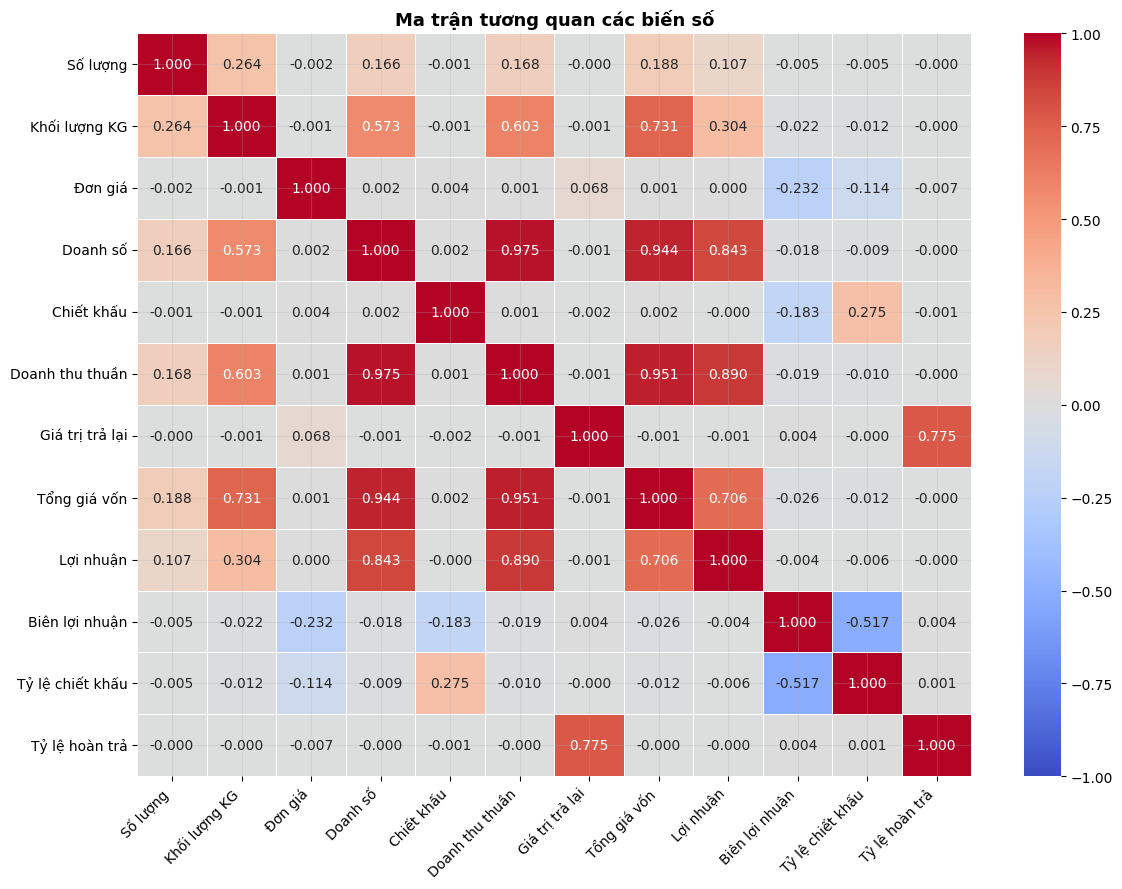

In [12]:
corr_cols = ['Số lượng', 'Khối lượng KG', 'Đơn giá', 'Doanh số', 'Chiết khấu', 'Doanh thu thuần', 'Giá trị trả lại', 'Tổng giá vốn', 'Lợi nhuận', 'Biên lợi nhuận', 'Tỷ lệ chiết khấu', 'Tỷ lệ hoàn trả']
corr_cols = [col for col in corr_cols if col in sales.columns]
corr = sales[corr_cols].corr(numeric_only=True)
display(corr)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr.fillna(0),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Ma trận tương quan các biến số', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 10. Ghi nhận đặc điểm dữ liệu

Phần này chỉ tóm tắt đặc điểm kỹ thuật của dữ liệu để làm cơ sở cho các bước phân tích sau.

In [13]:
summary_notes = [
    'Dữ liệu đã được hợp nhất thành một bảng final dùng chung cho phân tích.',
    'Các biến thời gian đã có sẵn Năm, Tháng, Quý và Năm-Tháng.',
    'Các biến số kinh doanh chính đã có thể mô tả bằng thống kê summary và biểu đồ phân bố.',
    'Các cột phân loại có thể dùng để tạo chiều phân tích trong data mart và Tableau.',
    'Các cột tỷ lệ có thể còn null khi mẫu số bằng 0; cách giữ null giúp tránh tạo tỷ lệ sai.',
    'Duplicate được hiển thị để giải thích chất lượng dữ liệu, không tự động loại bỏ nếu chưa có căn cứ nghiệp vụ.'
]
for i, note in enumerate(summary_notes, start=1):
    print(f'{i}. {note}')

1. Dữ liệu đã được hợp nhất thành một bảng final dùng chung cho phân tích.
2. Các biến thời gian đã có sẵn Năm, Tháng, Quý và Năm-Tháng.
3. Các biến số kinh doanh chính đã có thể mô tả bằng thống kê summary và biểu đồ phân bố.
4. Các cột phân loại có thể dùng để tạo chiều phân tích trong data mart và Tableau.
5. Các cột tỷ lệ có thể còn null khi mẫu số bằng 0; cách giữ null giúp tránh tạo tỷ lệ sai.
6. Duplicate được hiển thị để giải thích chất lượng dữ liệu, không tự động loại bỏ nếu chưa có căn cứ nghiệp vụ.
